# Análisis Exploratorio — Cáncer de piel (Chile)



## 1. Carga de datos y exploración inicial
**Descripción:** Se importan librerías, se carga el dataset y se inspeccionan dimensiones y tipos de variables.
**Qué hace el código:** Lee `dataset_chile_cancer_piel.csv`, muestra las primeras filas, dimensiones y `info()` del DataFrame.
**Interpretación (resultado actual):** El dataset contiene 1000 registros y 27 variables; no se detectan valores faltantes (0 nulos).

In [1]:
# Carga de librerías y dataset (usando helpers en src/)
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Asegurar que el paquete src sea importable desde la carpeta notebooks
sys.path.append(str(Path.cwd().parent))
from src.data_preprocessing import load_data

df = load_data('dataset_chile_cancer_piel.csv')

# Exploración inicial
display(df.head())


,Edad (años),Sexo,Peso (kg),Estatura (cm),IMC (calculado),Tabaquismo,Años-paquete,Consumo de alcohol,Inmunosupresión,Exposición solar crónica,...,Costra persistente,Bordes elevados/irregulares,Endurecimiento,Supuración,Cambio reciente de tamaño/color,Sutura o manipulación previa,Respuesta a antibióticos previos,Pérdida de peso involuntaria,Fiebre persistente,Fatiga
0,65,Hombre,64.9,170.7,22.3,No,0.0,Frecuente,Sí,No,...,Sí,No,Sí,No,Sí,No,Mala,No,No,No
1,47,Hombre,80.9,177.1,25.8,Sí,37.1,Ocasional,No,No,...,Sí,No,Sí,Sí,No,No,Parcial,No,Sí,No
2,80,Mujer,70.9,152.7,30.4,Sí,36.8,Ocasional,Sí,No,...,No,Sí,Sí,No,Sí,No,Mala,Sí,No,No
3,63,Mujer,73.7,154.6,30.8,Sí,21.3,Frecuente,No,Sí,...,No,No,No,Sí,Sí,Sí,Mala,No,No,No
4,60,Hombre,62.6,163.5,23.4,Sí,22.5,Frecuente,No,Sí,...,No,Sí,Sí,No,Sí,No,Nula,No,Sí,No


In [2]:
print('Dimensiones:', df.shape)
print('Información del dataframe:')
df.info()

Dimensiones: (1000, 27)
Información del dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Edad (años)                        1000 non-null   int64  
 1   Sexo                               1000 non-null   object 
 2   Peso (kg)                          1000 non-null   float64
 3   Estatura (cm)                      1000 non-null   float64
 4   IMC (calculado)                    1000 non-null   float64
 5   Tabaquismo                         1000 non-null   object 
 6   Años-paquete                       1000 non-null   float64
 7   Consumo de alcohol                 1000 non-null   object 
 8   Inmunosupresión                    1000 non-null   object 
 9   Exposición solar crónica           1000 non-null   object 
 10  Antecedentes personales de cáncer  1000 non-null   object 
 11  Cáncer

## 2. Distribución de variables numéricas
**Descripción:** Se generan histogramas y boxplots para variables numéricas clave: `Edad (años)`, `IMC (calculado)`, `Tamaño máximo (cm)`, `Peso (kg)`, `Estatura (cm)`.

**Qué hace el código:** Dibuja una serie de histogramas con KDE y boxplots :

El histograma con KDE permite ver la forma de la distribución: si se parece a una campana (simétrica), si está sesgada hacia un lado (asimetría), y dónde se concentra la mayoría de los datos.

El boxplot resume la información en cuatro puntos clave:

La mediana (línea dentro de la caja) → indica el valor central, donde está el 50%.

El rango intercuartílico (IQR) → la caja muestra el 50% de los datos centrales.

Los bigotes → marcan hasta dónde llegan los valores típicos sin ser considerados extremos.

Los outliers → puntos fuera de los bigotes, que representan valores poco frecuentes o extremos.



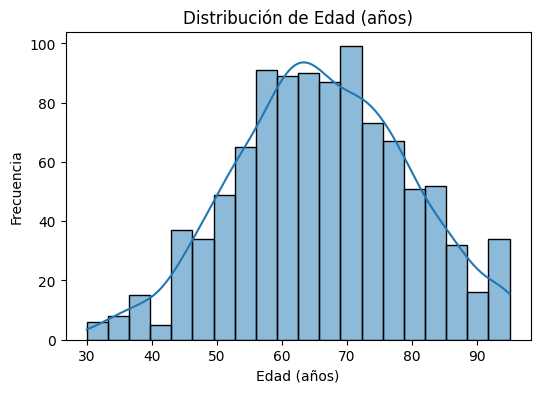

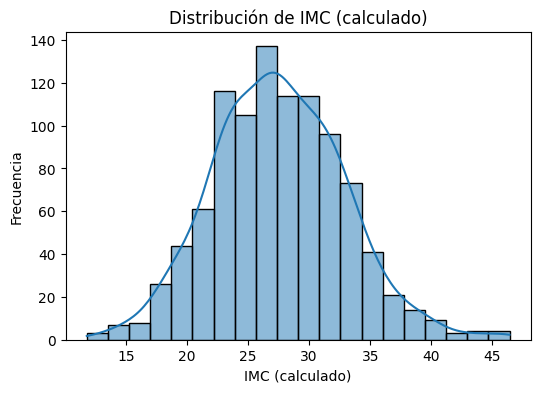

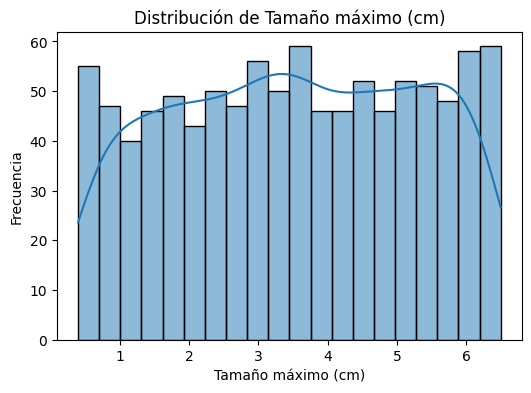

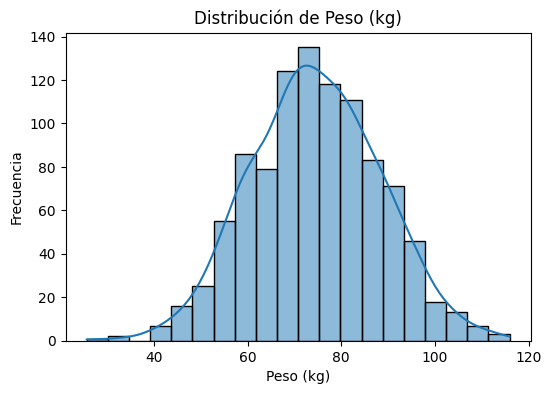

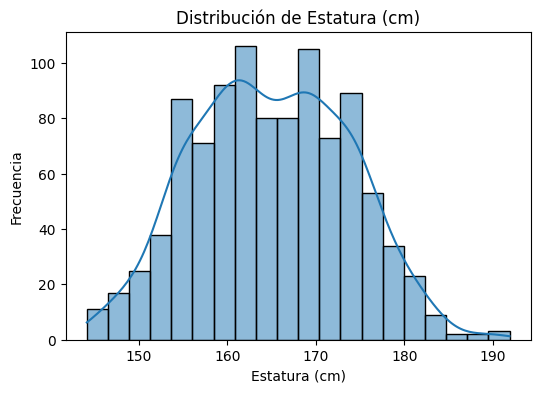

In [3]:
num_vars = ['Edad (años)', 'IMC (calculado)', 'Tamaño máximo (cm)', 'Peso (kg)', 'Estatura (cm)']
for col in num_vars:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col].dropna(), kde=True, bins=20)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

**Análisis (Distribución — Edad (años)):** En este histograma se observa la forma de la distribución de edades; identifica picos (modos), asimetría y colas. Un pico en rangos medios indica concentración de la muestra en adultos; una cola larga a la derecha sugiere algunos pacientes de mayor edad.

**Análisis (Distribución — IMC (calculado)):** Este gráfico muestra cómo se distribuye el IMC; observa si hay sesgo (asimetría) y si la mayor parte de la muestra se concentra en rangos normales o con sobrepeso. Si aparecen valores extremos, considerar revisión de datos.

**Análisis (Distribución — Tamaño máximo (cm)):** El gráfico muestra cómo se distribuyen los tamaños de las lesiones en la población. Se observa que los valores están bastante repartidos entre 1 y 6 cm, con frecuencias relativamente similares en cada intervalo. Esto indica que hay alta variabilidad en el tamaño de las lesiones: no todas siguen un patrón único, sino que aparecen tanto lesiones pequeñas como medianas y algunas más grandes.

La curva suavizada ayuda a ver la tendencia general: la distribución es relativamente uniforme, aunque pueden existir casos aislados con tamaños mayores que se consideran outliers y conviene analizarlos aparte.

**Análisis (Distribución — Peso (kg)):**El histograma muestra cómo se distribuyen los pesos en la población. La mayoría de las personas se concentran entre 70 y 80 kg, lo que se refleja en el pico central de la curva. La forma es bastante simétrica, similar a una campana, lo que indica que los valores extremos (muy bajos o muy altos) son menos frecuentes..

**Análisis (Distribución — Estatura (cm)):** Aquí se observa la distribución de las estaturas. La mayor parte de los individuos se ubica entre 160 y 170 cm, que es donde la curva alcanza su punto más alto. La forma también es cercana a una distribución normal, con menos personas en los extremos (muy bajas o muy altas).

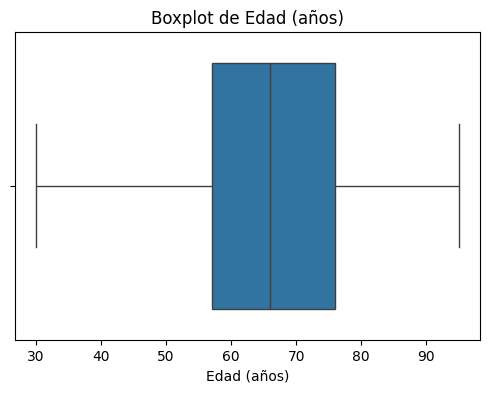

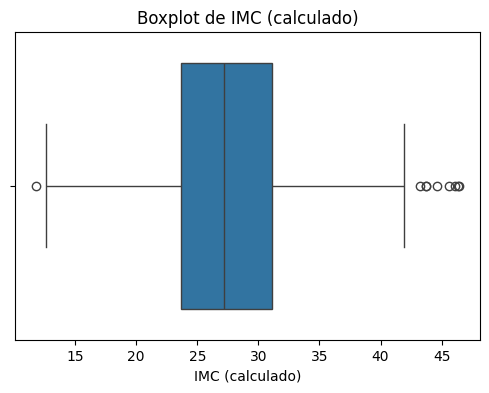

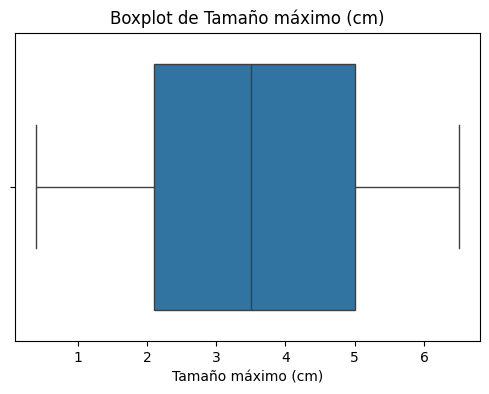

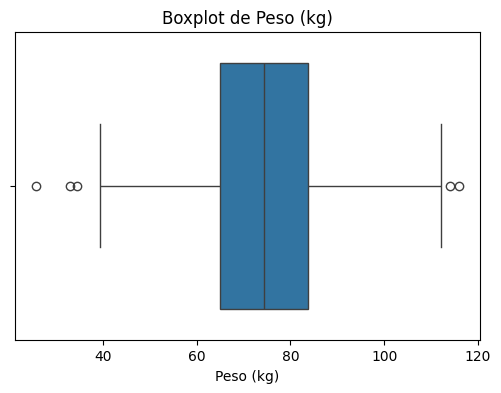

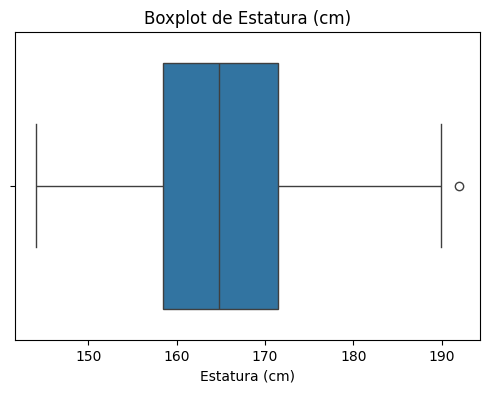

In [4]:
for col in num_vars:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

**Análisis (Boxplot — Edad (años)):** El gráfico muestra cómo se distribuyen las edades en la población. La mediana está cerca de los 67 años, lo que indica que la mitad de los pacientes tiene esa edad o menos. La mayoría de los valores se concentran entre 55 y 75 años, que es donde se encuentra el rango central. Los extremos del gráfico muestran que también hay personas más jóvenes (cerca de 30 años) y mayores (cerca de 90 años), aunque en menor cantidad.

**Análisis (Boxplot — IMC (calculado)):** Se observa que la mayoría de los valores de IMC se concentran en rangos normales (aprox. 18–30). Sin embargo, aparecen algunos casos más altos que se consideran outliers, lo que refleja personas con obesidad marcada.

**Análisis (Boxplot — Tamaño máximo (cm)):** La mayoría de las lesiones se ubican entre 1 y 6 cm, con una distribución relativamente compacta. No se aprecian demasiados valores fuera de rango.

**Análisis (Boxplot — Peso (kg)):**El peso se concentra en rangos medios (60–90 kg), aunque hay valores bajos y altos que sobresalen como outliers.

**Análisis (Boxplot — Estatura (cm)):**La estatura se concentra en torno a 160–170 cm, con un rango esperado para la población. Se observa algún valor extremo cercano a 190 cm.

## 3. Distribución de variables categóricas
**Descripción:** Se muestran conteos y proporciones para variables categóricas relevantes: `Sexo`, `Tabaquismo`, `Consumo de alcohol`, `Inmunosupresión`, `Exposición solar crónica`, `Localización de la lesión`.

**Qué hace el código:** Dibuja gráficos de barras ordenados por frecuencia para cada variable categórica.

**Interpretación:** Permiten caracterizar la población del estudio (por ejemplo, predominio de un sexo, prevalencia de tabaquismo, etc.). Estas proporciones ayudan a identificar factores de riesgo más frecuentes en la muestra.

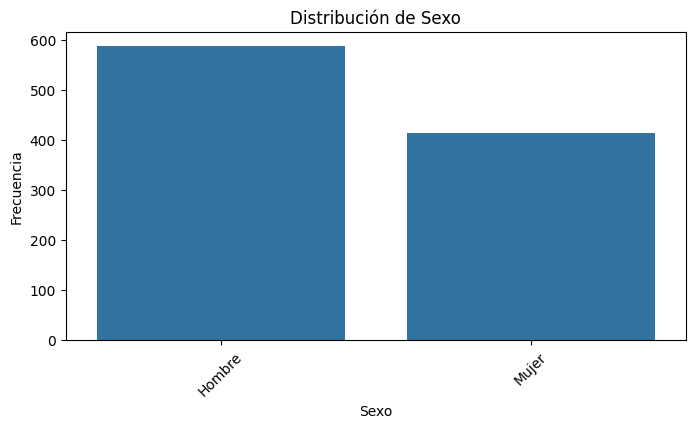

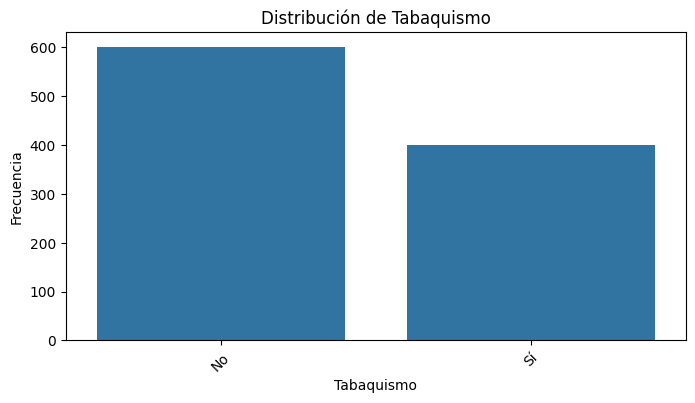

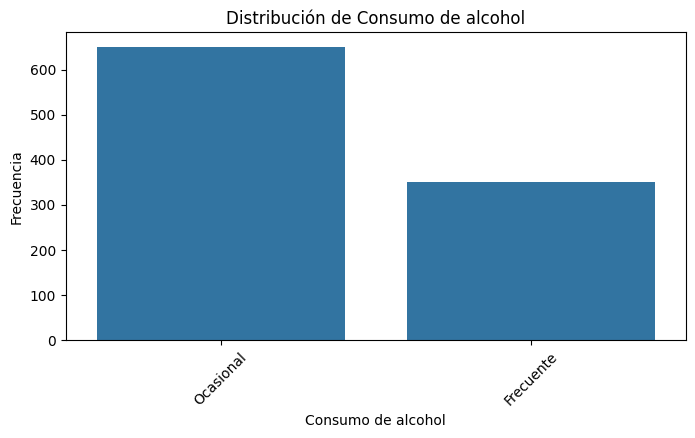

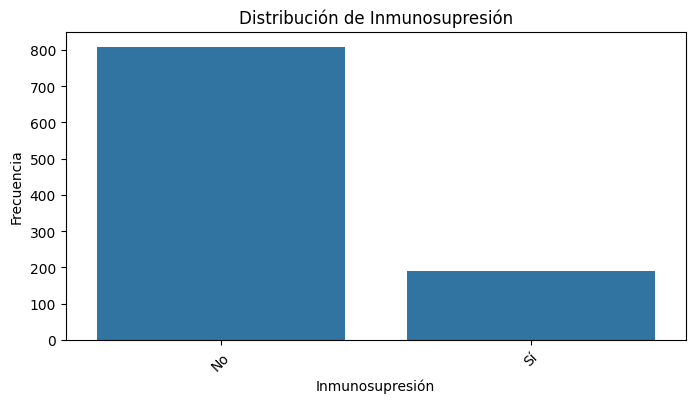

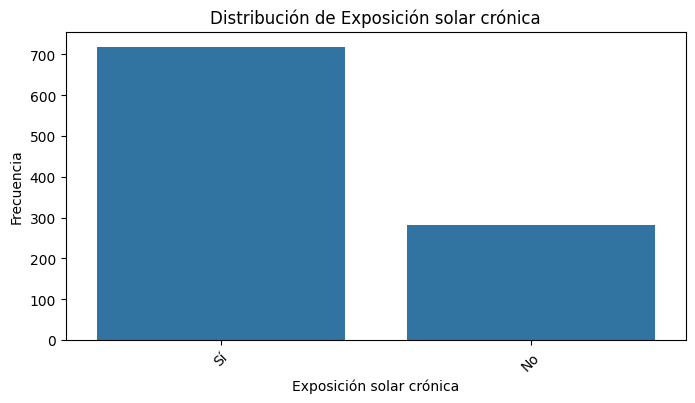

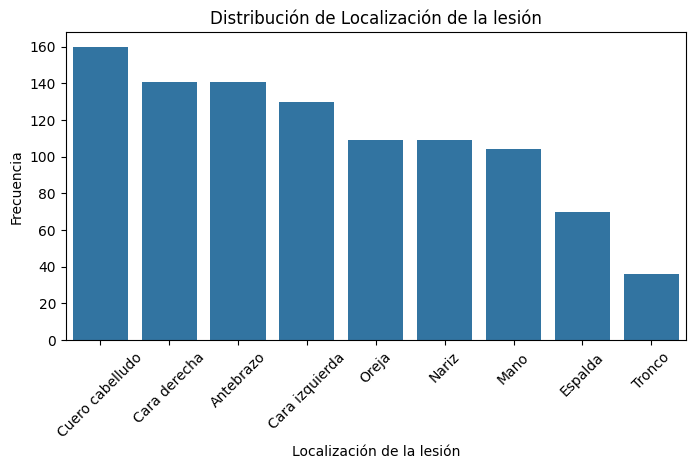

In [5]:
cat_vars = ['Sexo', 'Tabaquismo', 'Consumo de alcohol', 'Inmunosupresión', 'Exposición solar crónica', 'Localización de la lesión']
for col in cat_vars:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)
    plt.show()

**Análisis (Barras — Sexo):** Muestra la proporción de cada sexo en la muestra. Indica si hay predominio de uno u otro y ayuda a interpretar diferencias en otras variables.

**Análisis (Barras — Tabaquismo):** Indica cuántos pacientes fuman; si la barra de 'sí' es alta, sugiere mayor prevalencia de tabaquismo en la muestra.

**Análisis (Barras — Consumo de alcohol):** Muestra la frecuencia de consumo; útil para relacionarlo con otras variables clínicas.

**Análisis (Barras — Inmunosupresión):** Revela cuántos pacientes están inmunosuprimidos; esto puede influir en la presentación clínica de las lesiones.

**Análisis (Barras — Exposición solar crónica):** Indica la prevalencia de exposición solar crónica; alta exposición es un factor de riesgo importante para cáncer de piel.

**Análisis (Barras — Localización de la lesión):** Muestra las localizaciones más frecuentes. Observa si regiones expuestas al sol (cara, cuello, oreja) son más comunes; esto apoya la relación con exposición solar.

## 4. Correlaciones entre variables numéricas
**Descripción:** Cálculo de matriz de correlación y visualización con un heatmap para identificar relaciones lineales entre variables numéricas.

**Qué hace el código:** Calcula `df.corr()` y dibuja un `heatmap` con anotaciones.

**Interpretación:** Se espera observar alta correlación entre `IMC (calculado)`, `Peso (kg)` y `Estatura (cm)` (peso y estatura influyen en IMC); también pueden existir relaciones moderadas entre `Edad (años)` y `Tamaño máximo (cm)`.

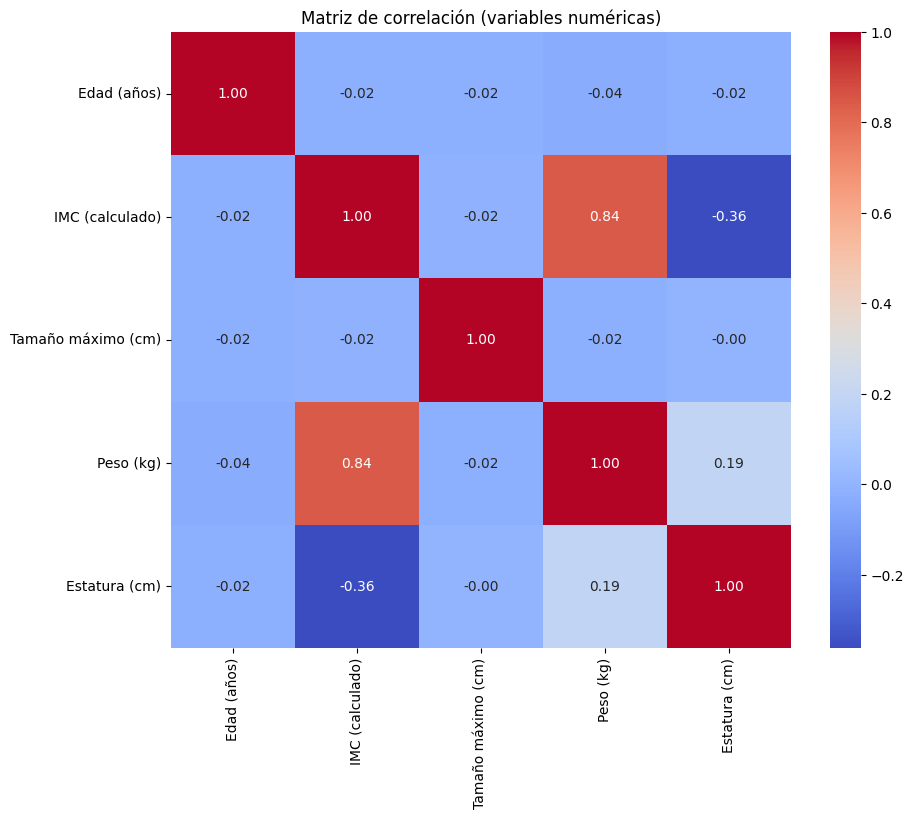

In [6]:
plt.figure(figsize=(10,8))
corr = df[num_vars].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación (variables numéricas)')
plt.show()

**Análisis (Heatmap — Correlaciones):** El mapa muestra la fuerza y dirección de correlaciones entre variables numéricas. Observa valores cercanos a 1 o -1 para relaciones fuertes (p. ej. IMC con Peso). Las correlaciones moderadas con 'Tamaño máximo (cm)' indicarían relación con edad u otras variables.

Un heatmap (mapa de calor) es una visualización gráfica que usa colores para representar valores numéricos dentro de una matriz o tabla. En el contexto de análisis de datos, se utiliza mucho para mostrar correlaciones entre variables

## 5. Análisis de relaciones de variables 
**Descripción:** Comparaciones entre pares de variables para detectar relaciones y diferencias entre grupos (ej.: `Tamaño máximo` vs `Tabaquismo`, `IMC` vs `Sexo`, `Edad` vs `Tamaño máximo`).

**Qué hace el código:** Dibuja `boxplots, barplot` y `regplot` para visualizar tendencias y diferencias.



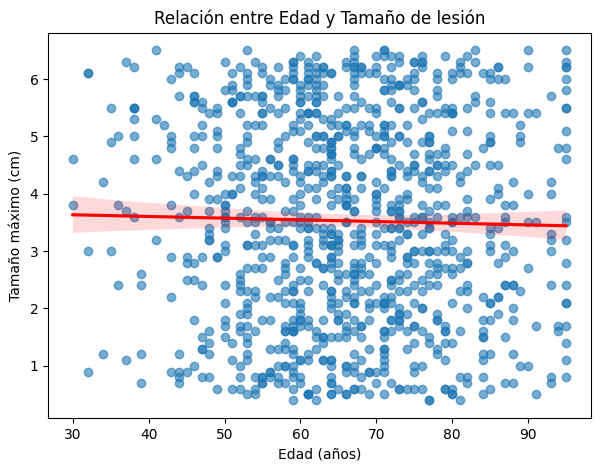

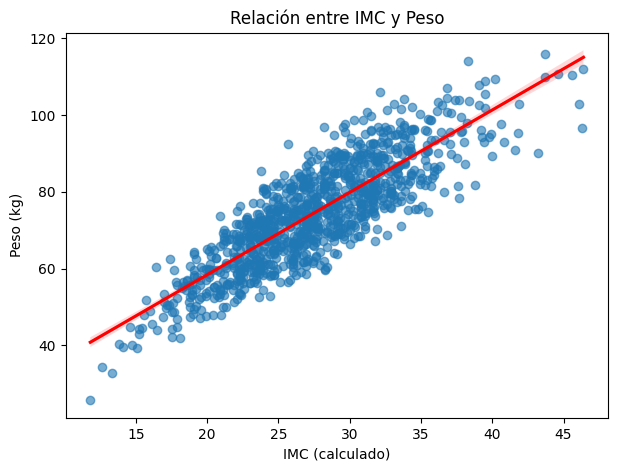

In [7]:
# Edad vs Tamaño de lesión con línea de regresión
plt.figure(figsize=(7,5))
sns.regplot(x='Edad (años)', y='Tamaño máximo (cm)', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Relación entre Edad y Tamaño de lesión')
plt.show()

# IMC vs Peso con línea de regresión
plt.figure(figsize=(7,5))
sns.regplot(x='IMC (calculado)', y='Peso (kg)', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Relación entre IMC y Peso')
plt.show()

**Análisis (Regplot — Edad vs Tamaño de lesión):** El gráfico muestra cómo varía el tamaño de las lesiones según la edad de los pacientes. Cada punto representa un caso individual, y la línea roja indica la tendencia general.

Se observa una leve tendencia negativa: a medida que aumenta la edad, el tamaño promedio de las lesiones tiende a ser un poco menor.

La dispersión es amplia, lo que significa que hay bastante variabilidad: personas de la misma edad pueden tener lesiones de tamaños muy distintos.

No se aprecia una relación fuerte ni lineal perfecta, pero sí una inclinación que sugiere que los pacientes más jóvenes tienden a presentar lesiones algo más grandes.

**Análisis (Regplot — IMC vs Peso):** El gráfico muestra cómo se relacionan el índice de masa corporal (IMC) y el peso de los pacientes.

Se observa una correlación positiva muy marcada: a medida que aumenta el IMC, también lo hace el peso.

Los puntos siguen bastante bien la línea de tendencia roja, lo que indica que la relación es fuerte y consistente.

La dispersión es baja en comparación con otros gráficos, lo que significa que el peso explica gran parte de la variación en el IMC.

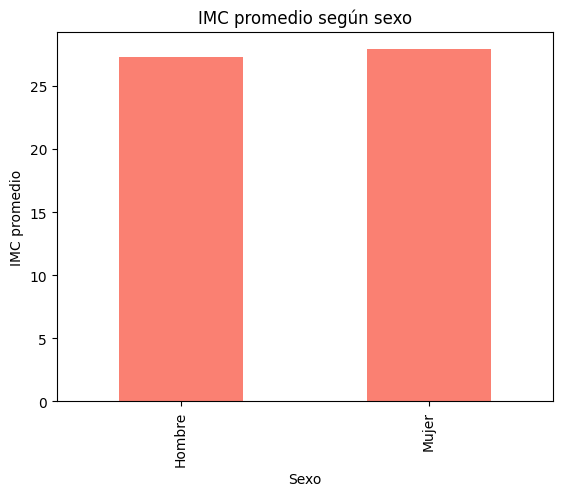

In [8]:
df.groupby("Sexo")["IMC (calculado)"].mean().plot(kind="bar", color="salmon")
plt.title("IMC promedio según sexo")
plt.xlabel("Sexo")
plt.ylabel("IMC promedio")
plt.show()


**Análisis (Bar — IMC promedio según sexo):** El gráfico muestra que el IMC promedio es prácticamente igual en hombres y mujeres (alrededor de 27–28).

no hay diferencias relevantes entre sexos en cuanto al IMC, lo que indica que ambos grupos tienen características corporales similares en este aspecto.

C:\Users\marti\AppData\Local\Temp\ipykernel_28992\52643985.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Sexo", y="Tamaño máximo (cm)", data=df,
C:\Users\marti\AppData\Local\Temp\ipykernel_28992\52643985.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sexo", y="Tamaño máximo (cm)", data=df,


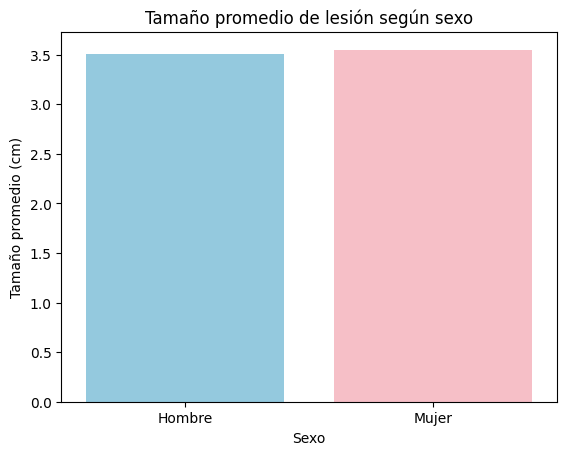

In [9]:
sns.barplot(x="Sexo", y="Tamaño máximo (cm)", data=df,
            estimator=np.mean, ci=None, palette=["skyblue","lightpink"])
plt.title("Tamaño promedio de lesión según sexo")
plt.ylabel("Tamaño promedio (cm)")
plt.show()


**Análisis (Bar — Tamaño promedio según sexo):** Aquí se comparan los tamaños promedio de las lesiones entre hombres y mujeres. Ambos grupos presentan valores muy cercanos (≈3.5 cm). el tamaño de las lesiones es similar en ambos sexos, sin diferencias destacables.

C:\Users\marti\AppData\Local\Temp\ipykernel_28992\2678720218.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Localización de la lesión", y="Tamaño máximo (cm)", data=df,
C:\Users\marti\AppData\Local\Temp\ipykernel_28992\2678720218.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Localización de la lesión", y="Tamaño máximo (cm)", data=df,


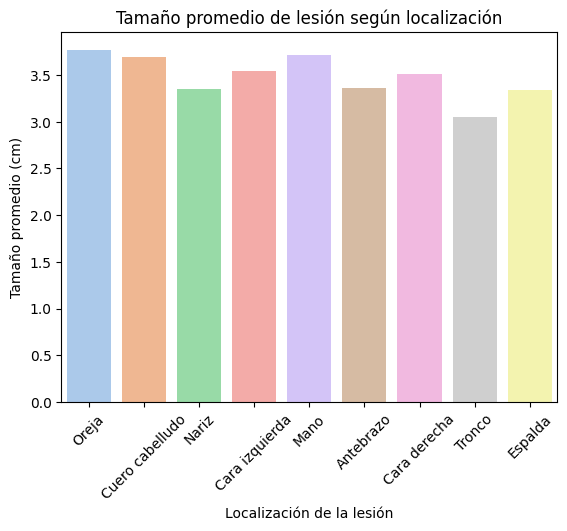

In [10]:
sns.barplot(x="Localización de la lesión", y="Tamaño máximo (cm)", data=df,
            estimator=np.mean, ci=None, palette="pastel")
plt.title("Tamaño promedio de lesión según localización")
plt.xticks(rotation=45)
plt.ylabel("Tamaño promedio (cm)")
plt.show()


**Análisis (Bar — Tamaño promedio según localización):** Este gráfico muestra cómo varía el tamaño promedio de las lesiones según la parte del cuerpo. Se observa que en zonas como oreja y mano los tamaños promedio son algo mayores, mientras que en otras localizaciones (cara, tronco, espalda) los valores son más homogéneos. la localización influye ligeramente en el tamaño de la lesión, destacando oreja y mano como áreas con lesiones más grandes.

## 6. Valores faltantes
**Descripción:** Conteo y visualización de valores faltantes para confirmar integridad del dataset.
**Qué hace el código:** Calcula el conteo de `isnull()` por columna y muestra un `heatmap` con valores faltantes.
**Interpretación (resultado actual):** No se detectan valores nulos; el dataset está completo y listo para modelado.

Valores faltantes por columna:
Edad (años)                          0
Sexo                                 0
Peso (kg)                            0
Estatura (cm)                        0
IMC (calculado)                      0
Tabaquismo                           0
Años-paquete                         0
Consumo de alcohol                   0
Inmunosupresión                      0
Exposición solar crónica             0
Antecedentes personales de cáncer    0
Cáncer familiar 1er grado (tipo)     0
Localización de la lesión            0
Tiempo de evolución                  0
Tamaño máximo (cm)                   0
Dolor                                0
Ulceración o sangrado espontáneo     0
Costra persistente                   0
Bordes elevados/irregulares          0
Endurecimiento                       0
Supuración                           0
Cambio reciente de tamaño/color      0
Sutura o manipulación previa         0
Respuesta a antibióticos previos     0
Pérdida de peso involuntaria     

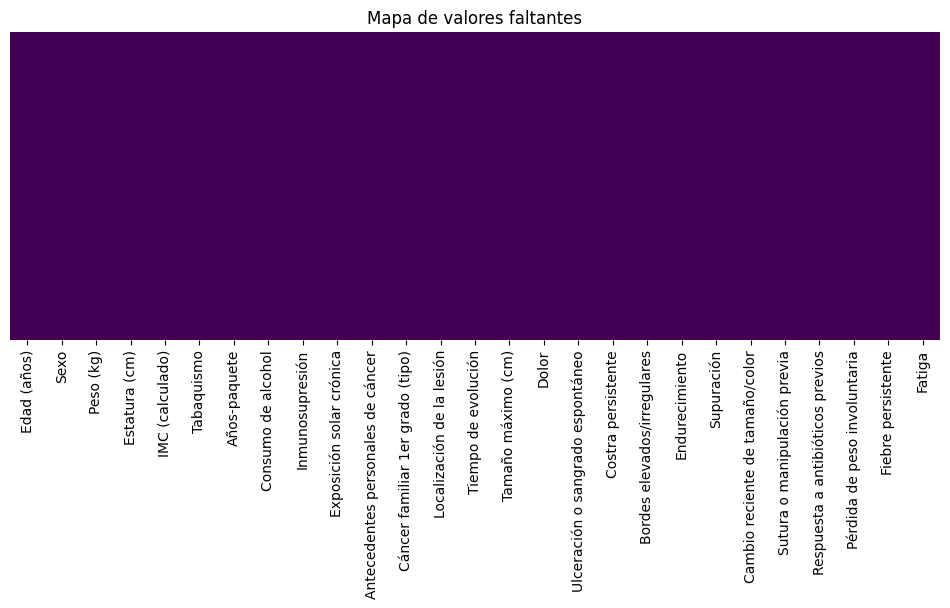

In [11]:
# Conteo de valores faltantes
print('Valores faltantes por columna:')
print(df.isnull().sum())

# Heatmap de nulos (si los hay)
plt.figure(figsize=(12,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de valores faltantes')
plt.show()

## 7. Conclusiones
- **Dimensiones y calidad:** 1000 registros × 27 variables, sin valores faltantes.
- **Distribuciones:** Variables numéricas muestran distribuciones esperadas; `Tamaño máximo (cm)` presenta outliers a investigar.
- **Variables categóricas:** Permiten caracterizar la muestra y detectar factores de riesgo prevalentes (sexo, tabaquismo, exposición solar).
- **Correlaciones:** Alta correlación esperada entre IMC, peso y estatura; relación moderada entre edad y tamaño de lesión.
- **Siguientes pasos sugeridos:** tratamiento de outliers, codificación de categóricas, ingeniería de variables y modelado predictivo.